In [1]:
# CELL 0: CONFIGURATION — Update paths before running

# All configurable paths are defined here in one place.
# Update these to match your local setup before running any cells.

# Path to the folder on Google Drive containing the zip files
# Update this to match your Google Drive folder structure
DRIVE_FOLDER = "/content/drive/MyDrive/Zip_Datasets_Galaxeye"

# Path where dataset will be extracted
DATA_ROOT = "/content/dataset"

# Path where model weights and outputs will be saved
SAVE_DIR = DRIVE_FOLDER  # Saves to Drive so weights persist across sessions

# Model checkpoint path
MODEL_PATH = f"{SAVE_DIR}/best_model.pth"

print("Configuration loaded successfully!")
print(f"Drive folder: {DRIVE_FOLDER}")
print(f"Data root:    {DATA_ROOT}")
print(f"Model path:   {MODEL_PATH}")

Configuration loaded successfully!
Drive folder: /content/drive/MyDrive/Zip_Datasets_Galaxeye
Data root:    /content/dataset
Model path:   /content/drive/MyDrive/Zip_Datasets_Galaxeye/best_model.pth


In [2]:
# CELL 1: Import necessary libraries and model training:

# Standard libraries for file handling and numerical operations
import os
import zipfile
from PIL import Image # For loading and inspecting tif image files.
import numpy as np
import matplotlib.pyplot as plt # For visulaising images and results

# Importing all the libraries for building and training the model

import torch                    # Core Pytorch library
import torch.nn as nn           # Neural Network building blocks
import torch.optim as optim     # Optimizers (e.g., Adam)
from torch.utils.data import Dataset, DataLoader    # Data Loading Utilities
import torchvision.transforms as transforms         # Image Transformations
import torchvision.transforms.functional as TF      # Function Transforms
from torchvision import models  # Pretrained models for encoder
import os
import random
from tqdm import tqdm           # Progress bar during training

In [3]:
# CELL 2: Environment Setup (Mounts Drive and prompts authentication):

# To mount Google Drive and access the zipped dataset files.
# This will prompt to authenticate the Google account containing the zipped files.
os.makedirs('/content/drive', exist_ok=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# CELL 3: Unzip Datasets from Google Drive:

# Path to the folder containing zip files on Drive
# Check the exact folder name and path and update below accordingly
# Note: Running this cell will take some time since the train dataset is of about 8GB and so unzipping it takes some time.

folder = DRIVE_FOLDER

# Mapping each split name to its corresponding zip file path
zips = {
    "train": f"{folder}/train.zip", # ~8.21 GB
    "test" : f"{folder}/test.zip",  # ~186 MB
    "val" : f"{folder}/val.zip"     # ~980 MB
}

# Directory where all extracted data will be stored
extract_path = DATA_ROOT
os.makedirs(extract_path, exist_ok=True)

# Extract each zip file into the dataset directory
for split, zip_path in zips.items():
  print(f"Unzipping {split}...")
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
  print(f"Done with {split}!\n")
print("\nAll splits extracted successfully.")

Unzipping train...
Done with train!

Unzipping test...
Done with test!

Unzipping val...
Done with val!


All splits extracted successfully.


In [6]:
# CELL 4: Single Sample Inspection

# This is to verify the modality, size, and label format of only one example
# Before running full dataset analysis

# Picking the first sample from the train dataset alphabetically
sample = sorted(os.listdir("/content/dataset/train/pre-event"))[0]
print("Inspecting sample (from train only): ", sample, "\n")

# Load the pre-event, post-event, and target mask for this sample
# All three share the same filename, so this is how matched pairs are identified
pre = Image.open(f"/content/dataset/train/pre-event/{sample}")
post = Image.open(f"/content/dataset/train/post-event/{sample}")
mask = Image.open(f"/content/dataset/train/target/{sample}")

# Pre-event image (expected to be EO (RGB, 3 channels))
print("PRE")
print("Mode:", pre.mode) # This will determine whether EO or SAR
print("Size:", pre.size) # Expected: (1024, 1024)

# Post-event image (expected to be SAR (grayscale, 1 channel))
print("\nPOST")
print("Mode:", post.mode) # This will determine whether EO or SAR
print("Size:", post.size) # Expected: (1024, 1024)

# Target Mask (binary change label map)
print("\nMASK")
print("Mode:", mask.mode) # Grayscale or RGB
print("Size:", mask.size) # Expected: (1024, 1024), same as images

# Check what label values exist in this mask before remapping
# Expected: [0 1] if already remapped, may contain [0 1 2 3] if not
print("\nMask unique values:")
print(np.unique(np.array(mask)))

Inspecting sample (from train only):  scene_01_000001_building_damage.tif 

PRE
Mode: RGB
Size: (1024, 1024)

POST
Mode: L
Size: (1024, 1024)

MASK
Mode: L
Size: (1024, 1024)

Mask unique values:
[0 1]


In [7]:
# CELL 5: Full Dataset Analysis

# To analyse modality types and class imbalance across all splits

# Root directory containing train, val, and test folders
data_root = "/content/dataset"
splits = ["train", "val", "test"]

for split in splits:
  print(f"\n {'='*50}")
  print(f"\nSPLIT: {split}")
  print(f"\n{'='*50}")

  # Paths to the three subfolders within each split
  pre_path = os.path.join(data_root, split, "pre-event")
  post_path = os.path.join(data_root, split, "post-event")
  target_path = os.path.join(data_root, split, "target")

  # Get sorted list of all image filenames in this split
  filenames = sorted(os.listdir(pre_path))
  print("Total samples:", len(filenames))

  # Counters for all possible modality pair combinations
  # This tells us whteher pairs are EO+EO, SAR+SAR, EO+SAR, or SAR+EO
  eo_eo = sar_sar = eo_sar = sar_eo = 0

  # Counters for measuring class imbalance across all masks
  total_change = 0
  total_pixels = 0

  # Modality Analysis
  for fname in filenames:
    pre_img = Image.open(os.path.join(pre_path, fname))
    post_img = Image.open(os.path.join(post_path, fname))

    # Determine modality from image mode:
    # RGB = EO (Electro Optical, 3 channel colour image)
    # L = SAR (Synthetic Aperture Radar, grayscale, 1 channel)
    pre_mode = "EO" if pre_img.mode == "RGB" else "SAR"
    post_mode = "EO" if post_img.mode == "RGB" else "SAR"

    # Increment in the appropriate pair counter
    if pre_mode == "EO" and post_mode == "EO": eo_eo += 1
    elif pre_mode == "SAR" and post_mode == "SAR": sar_sar += 1
    elif pre_mode == "EO" and post_mode == "SAR": eo_sar += 1
    else: sar_eo += 1

  # Class Imbalance Analysis
  for fname in sorted(os.listdir(target_path)):
    arr = np.array(Image.open(os.path.join(target_path, fname)))

    # Apply mandatory label remapping as specified in the assignment:
    # Original labels: 0=Background, 1=Intact, 2=Damaged, 3=Destroyed
    # Remapped labels: 0=no-change (Background+Intact), 1=Change (Damaged+Destroyed)
    # np.where applies this rule to every pixel simultaneously
    remapped = np.where(arr >= 2, 1, 0)

    # Accumulate change and total pixel counts
    total_change += (remapped == 1).sum()
    total_pixels += remapped.size

  # Print Results
  print("EO + EO pairs: ", eo_eo, "\n")
  print("SAR + SAR pairs: ", sar_sar, "\n")
  print("EO + SAR pairs: ", eo_sar, "\n")
  print("SAR + EO pairs: ", sar_eo, "\n")

  change_pct = total_change / total_pixels * 100
  print("Change in pixels: ", change_pct.round(2), "%")
  print("No change in pixels: ", 100-change_pct.round(2), "%")



SPLIT: train

Total samples: 2781
EO + EO pairs:  0 

SAR + SAR pairs:  0 

EO + SAR pairs:  2781 

SAR + EO pairs:  0 

Change in pixels:  1.57 %
No change in pixels:  98.43 %


SPLIT: val

Total samples: 334
EO + EO pairs:  0 

SAR + SAR pairs:  0 

EO + SAR pairs:  334 

SAR + EO pairs:  0 

Change in pixels:  2.2 %
No change in pixels:  97.8 %


SPLIT: test

Total samples: 77
EO + EO pairs:  0 

SAR + SAR pairs:  0 

EO + SAR pairs:  77 

SAR + EO pairs:  0 

Change in pixels:  0.75 %
No change in pixels:  99.25 %


In [8]:
# CELL 6: Check GPU is available and set device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# If it says cuda — perfect, GPU is active and we're ready to build.
# If it says cpu — we need to fix the GPU setting before proceeding.


Using device: cuda


In [9]:
# CELL 7: Dataset Class
# This class tells PyTorch how to load one image pair at a time
# It handles loading, label remapping, augmentation and tensor conversion

# Creating a new class that inherits from PyTorch's built-in Dataset class
class ChangeDetectionDataset(Dataset):
  def __init__(self, root_dir, split, augment=False):
    """
    root_dir: path to the dataset folder e.g. "/content/dataset"
    split: one of "train", "val", or "test"
    augment: whether to apply data augmentation (only for training)
    """
    self.pre_dir = os.path.join(root_dir, split, "pre-event")
    self.post_dir = os.path.join(root_dir, split, "post-event")
    self.target_dir = os.path.join(root_dir, split, "target")
    self.augment = augment

    # Get sorted list of filenames in this split
    self.filenames = sorted(os.listdir(self.pre_dir))

  def __len__(self):
    # Returns number of samples in this split
    return len(self.filenames)

  def __getitem__(self, idx):
    """
    Loads and returns one sample given an index.
    This is called automatically by the DataLoader during training.
    """
    fname = self.filenames[idx]

    # Load pre-event (EO, RGB, 3 channels) and post-event (SAR, grayscale, 1 channel)
    pre = Image.open(os.path.join(self.pre_dir, fname)).convert("RGB")
    post = Image.open(os.path.join(self.post_dir, fname)).convert("L")
    mask = Image.open(os.path.join(self.target_dir, fname))

    # REsize all images to 256x256
    # 1024x1024 is too large to fit in GPU memory during training
    # 256x256 is a standard size that balances detail and memory usage
    pre = pre.resize((256, 256), Image.BILINEAR)
    post = post.resize((256, 256), Image.BILINEAR)
    mask = mask.resize((256, 256), Image.NEAREST)
    # Note:
    # NEAREST for mask because we do not want to interpolate label values
    # So that it picks the closest pixel value without averaging label values (0 and 1)
    # BILINEAR for images because smooth interpolation looks better for photos

    # Apply data augmentation if enabled (training only)
    # This randomly flips images to create more variety
    # Helping the model generalise and reduce overfitting
    if self.augment:
      # Random horizontal flip
      if random.random() > 0.5:
        pre = TF.hflip(pre)
        post = TF.hflip(post)
        mask = TF.hflip(mask)

      # Random vertical flip
      if random.random() > 0.5:
        pre = TF.vflip(pre)
        post = TF.vflip(post)
        mask = TF.vflip(mask)

    # Convert images to Pytorch tensors and normalise pixel values
    # Normalisation scales pixel values to a standard range
    # which helps the model train faster and more stably
    pre = TF.to_tensor(pre)  # Shape: (3, 256, 256) - 3 channels EO
    post = TF.to_tensor(post) # Shape: (1, 256, 256) - 1 channel SAR

    # Concatenate EO and SAR along the channel dimension
    # Result shape: (4, 256, 256) - our 4 channel input
    # Early fusion
    image = torch.cat([pre, post], dim = 0)

    # Convert mask to numpy, apply mandatory label remapping:
    # Original: 0=Background, 1=Intact, 2=Damaged, 3=Destroyed
    # Remapped: 0=No-Change, 1=Change
    mask = np.array(mask)
    mask = np.where(mask >= 2, 1, 0)

    # Convert mask to PyTorch tensor
    # Long type is required for loss function computation
    mask = torch.tensor(mask, dtype=torch.long)

    return image, mask

# Create dataset objects for each split
# augment = True only for training. We never augment val or test
train_dataset = ChangeDetectionDataset(DATA_ROOT, "train", augment=True)
val_dataset   = ChangeDetectionDataset(DATA_ROOT, "val",   augment=False)
test_dataset  = ChangeDetectionDataset(DATA_ROOT, "test",  augment=False)

# Create DataLoaders which will handle batching and shuffling automatically
# batchsize=8 means the model sees 8 image pairs at once
# shuffle=True for training so the model doesn't see images in the same order every epoch
train_loader = DataLoader(train_dataset, batch_size = 8, shuffle = True, num_workers = 0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size = 8, shuffle = False, num_workers = 0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = 8, shuffle = False, num_workers = 0, pin_memory = True)

print("Train samples: ", len(train_dataset))
print("Val samples: ", len(val_dataset))
print("Test samples: ", len(test_dataset))

# Verify that one batch loads correctly:
images, masks = next(iter(train_loader))
print("Batch image shape: ", images.shape)      # Expected: (8, 4, 256, 256), 8=batch size, 4 channels, 256,256 image size after resizing
print("Batch mask shape: ", masks.shape)        # Expected: (8, 256, 256) 8 btach size, 256, 256 image size
print("Unique mask values: ", masks.unique())   # Expected: tensor([0, 1]) Confirms the label remapping worked. Only 0 and 1 present, no 2s or 3s.



Train samples:  2781
Val samples:  334
Test samples:  77
Batch image shape:  torch.Size([8, 4, 256, 256])
Batch mask shape:  torch.Size([8, 256, 256])
Unique mask values:  tensor([0, 1])


In [10]:
# CELL 8: U-Net Model Definition
# A U-Net built from scratch with encoder, bottleneck, decoder and skip connections
# Input: 4-channel image (3 EO + 1 SAR)
# Output: 2-class pixel-level change mask (Change / No Change)

class DoubleConv(nn.Module):
  """
  Two consecutive convolutional layers, each followed by
  Batch Normalisation and ReLU activation.
  This is the basic building block used throughout the U-Net.

  What is a convolution?
  It slides a small filter across the image, detecting local patterns like edges, textures, and shapes at each location.

  What is Batch Normalisation?
  Keeps the values flowing through the network in a stable range, making training faster and more stable.

  What is ReLU?
  A simple activation function: If the value is negative, set it to 0. This introduces non-linearity, allowing the network to learn
  complex patterns beyond simple linear relationships.
  """

  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Sequential(
        # First convolution
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        # Second convolution
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.conv(x)

class UNet(nn.Module):
  """
  Full U-Net architecture with encoder, bottleneck, decoder and skip connections.

  Encoder: Progressively compresses the image, learning what features are present.
  Bottleneck: The deepest, most compressed representation.
  Decoder: Progressively expands back to original size, predicting where the changes are.
  Skip connections: Bridges from encoder to decoder that preserve spatial detail.
  """

  def __init__(self, in_channels = 4, out_channels = 2, features = [64, 128, 256, 512]):
    """
    in_channels = 4: Our 4-channel input (3 EO + 1 SAR)
    out_channels = 2: Two classes (No-change and Change)
    features: Number of filters at each encoder level
    """

    super().__init__()

    # ENCODER
    # Each level doubles the number of features while halving spatial size.
    # MaxPool2d halves the spatial dimensions (downsampling)
    self.encoder1 = DoubleConv(in_channels, features[0])        # 4 --> 64
    self.pool1 = nn.MaxPool2d(2)

    self.encoder2 = DoubleConv(features[0], features[1])        # 64 --> 128
    self.pool2 = nn.MaxPool2d(2)

    self.encoder3 = DoubleConv(features[1], features[2])        # 128 --> 256
    self.pool3 = nn.MaxPool2d(2)

    self.encoder4 = DoubleConv(features[2], features[3])        # 256 --> 512
    self.pool4 = nn.MaxPool2d(2)

    # BOTTLENECK
    # Deepest point of the "U" (most abstract representation)
    self.bottleneck = DoubleConv(features[3], features[3]*2)    # 512 --> 1024

    # DECODER
    # Each level halves the number of features while doubling spatial size
    # ConvTranspose2d is the reverse of convolution i.e., it upsamples
    # Note: Input channels are doubled because of skip connections
    # We concatenate encoder features with decoder features

    self.upconv4 = nn.ConvTranspose2d(features[3]*2, features[3], kernel_size=2, stride=2)
    self.decoder4 = DoubleConv(features[3]*2, features[3])      # 1024 --> 512

    self.upconv3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
    self.decoder3 = DoubleConv(features[2]*2, features[2])      # 512 --> 256

    self.upconv2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
    self.decoder2 = DoubleConv(features[1]*2, features[1])      # 256 --> 128

    self.upconv1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
    self.decoder1 = DoubleConv(features[0]*2, features[0])      # 128 --> 64

    # OUTPUT LAYER
    # 1x1 convolution maps 64 features to 2 output classes (No-Change, Change)
    self.output = nn.Conv2d(features[0], out_channels, kernel_size=1)

  def forward(self, x):
      """
      Defines the forward pass, how data flows through the network.
      x: input tensor of shape (batch, 4, 256, 256)
      """

      # ENCODER PASS
      # Save encoder outputs for skip connections

      e1 = self.encoder1(x)               # (batch, 64,  256, 256)
      e2 = self.encoder2(self.pool1(e1))  # (batch, 128, 128, 128)
      e3 = self.encoder3(self.pool2(e2))  # (batch, 256, 64,  64)
      e4 = self.encoder4(self.pool3(e3))  # (batch, 512, 32,  32)

      # BOTTLENECK
      b = self.bottleneck(self.pool4(e4)) # (batch, 1024, 16, 16)

      # DECODER PASS with SKIP CONNECTIONS
      # Upsample then concatenate with corresponding encoder output
      d4 = self.upconv4(b)            # (batch, 512, 32, 32)
      d4 = torch.cat([d4, e4], dim=1) # (batch, 1024, 32, 32) — skip connection
      d4 = self.decoder4(d4)          # (batch, 512, 32, 32)

      d3 = self.upconv3(d4)           # (batch, 256, 64, 64)
      d3 = torch.cat([d3, e3], dim=1) # (batch, 512, 64, 64) — skip connection
      d3 = self.decoder3(d3)          # (batch, 256, 64, 64)

      d2 = self.upconv2(d3)           # (batch, 128, 128, 128)
      d2 = torch.cat([d2, e2], dim=1) # (batch, 256, 128, 128) — skip connection
      d2 = self.decoder2(d2)          # (batch, 128, 128, 128)

      d1 = self.upconv1(d2)           # (batch, 64, 256, 256)
      d1 = torch.cat([d1, e1], dim=1) # (batch, 128, 256, 256) — skip connection
      d1 = self.decoder1(d1)          # (batch, 64, 256, 256)

      # OUTPUT
      return self.output(d1)           # (batch, 2, 256, 256)


# Initialise the model and move it to GPU
model = UNet(in_channels=4, out_channels=2).to(device)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model initialised successfully!")
print("Total trainable parameters: ", total_params, ":,")

# Test with a dummy batch to confirm shapes are correct
dummy_input = torch.randn(2, 4, 256, 256).to(device)
dummy_output = model(dummy_input)
print("Input shape: ", dummy_input.shape)   # Expected: (2, 4, 256, 256)
print("Output shape: ", dummy_output.shape)  # Expected: (2, 2, 256, 256)

Model initialised successfully!
Total trainable parameters:  31038274 :,
Input shape:  torch.Size([2, 4, 256, 256])
Output shape:  torch.Size([2, 2, 256, 256])


In [11]:
# CELL 9: Loss Function and Optimiser

# DICE LOSS
# Directly optimises overlap between predicted and actual change mask
# Handles class imbalance naturally by focusing on the minority class
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        # smooth prevents division by zero when both prediction
        # and target are empty (no change pixels in image)
        self.smooth = smooth

    def forward(self, predictions, targets):
        # Convert raw model outputs to probabilities using softmax
        # Softmax converts two scores per pixel into probabilities that sum to 1
        predictions = torch.softmax(predictions, dim=1)

        # Extract probability of the Change class (index 1)
        predictions = predictions[:, 1, :, :]  # shape: (batch, 256, 256)

        # Convert target mask to float for calculation
        targets = targets.float()

        # Calculate Dice coefficient
        # Intersection = where both prediction and target agree there is change
        intersection = (predictions * targets).sum()

        # Dice = 2 * intersection / (total predicted change + total actual change)
        dice = (2.0 * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)

        # Return Dice Loss (1 - Dice coefficient)
        # When dice=1 (perfect), loss=0
        # When dice=0 (no overlap), loss=1
        return 1.0 - dice


# COMBINED LOSS
# Dice Loss handles class imbalance
# BCE Loss provides pixel-level training stability
# Together they give the best of both worlds
class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        # weight parameter gives more importance to Change class (label=1)
        # Since change pixels are ~1-2% of data, we weight them 10x higher
        self.bce  = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]).to(device))
        self.dice_weight = dice_weight
        self.bce_weight  = bce_weight

    def forward(self, predictions, targets):
        dice_loss = self.dice(predictions, targets)
        bce_loss  = self.bce(predictions, targets)
        # Weighted combination of both losses
        return self.dice_weight * dice_loss + self.bce_weight * bce_loss


# OPTIMISER
# Adam is the most widely used optimiser for deep learning
# It automatically adjusts the learning rate for each parameter
# learning_rate=1e-4 is a safe, standard starting point for U-Net
criterion = CombinedLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# LEARNING RATE SCHEDULER
# Reduces learning rate by half if validation loss stops improving for 5 epochs
# This helps the model fine-tune as it gets closer to the best solution
# Think of it like taking smaller steps as you get closer to your destination
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
print("Loss function, optimiser and scheduler initialised successfully!")

# Quick sanity check — compute loss on dummy batch
dummy_input  = torch.randn(2, 4, 256, 256).to(device)
dummy_target = torch.randint(0, 2, (2, 256, 256)).to(device)
dummy_output = model(dummy_input)
dummy_loss   = criterion(dummy_output, dummy_target)
print(f"Sanity check loss value: {dummy_loss.item():.4f}")
# This should print a number between 0 and 2 — just confirms loss works

Loss function, optimiser and scheduler initialised successfully!
Sanity check loss value: 0.5849


In [12]:
# CELL 10: Training Loop

def train_one_epoch(model, loader, criterion, optimizer):
    """
    Trains the model for one complete pass through the training data.
    Returns the average loss for this epoch.

    """
    # Set model to training mode
    # This enables dropout and batch normalisation to behave correctly
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc="Training"):
        # Move data to GPU
        images = images.to(device)
        masks  = masks.to(device)

        # Zero the gradients from the previous batch
        # If we don't do this, gradients accumulate and training goes wrong
        optimizer.zero_grad()

        # Forward pass — get model predictions
        outputs = model(images)

        # Compute loss — how wrong is the model?
        loss = criterion(outputs, masks)

        # Backward pass — compute gradients
        # This calculates how much each weight contributed to the error
        loss.backward()

        # Update weights using the gradients
        optimizer.step()

        total_loss += loss.item()

    # Return average loss across all batches
    return total_loss / len(loader)


def validate(model, loader, criterion):
    """
    Evaluates the model on the validation set without updating weights.
    Returns average validation loss.

    """
    # Set model to evaluation mode
    # This disables dropout and makes batch norm behave differently
    model.eval()
    total_loss = 0.0

    # torch.no_grad() tells PyTorch not to track gradients
    # This saves memory and speeds up evaluation
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validating"):
            images  = images.to(device)
            masks   = masks.to(device)
            outputs = model(images)
            loss    = criterion(outputs, masks)
            total_loss += loss.item()

    return total_loss / len(loader)


# TRAINING CONFIGURATION
NUM_EPOCHS       = 30
PATIENCE         = 7
patience_counter = 0
best_model_path  = MODEL_PATH

# RESUME SETTINGS
# Set RESUME = True to continue from last checkpoint
# Update START_EPOCH and BEST_VAL_LOSS based on last training output
RESUME         = True
START_EPOCH    = 20      # Last completed epoch
BEST_VAL_LOSS  = 0.5179  # Best val loss from last run

if RESUME and os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    best_val_loss = BEST_VAL_LOSS
    print(f"Resuming from epoch {START_EPOCH}, best val loss: {best_val_loss:.4f}")
else:
    best_val_loss = float('inf')
    START_EPOCH   = 0
    print("Starting fresh training...")

print("Starting training...\n")

# Change range(NUM_EPOCHS) to range(START_EPOCH, NUM_EPOCHS)
for epoch in range(START_EPOCH, NUM_EPOCHS):

    # Train for one epoch and get average training loss
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)

    # Evaluate on validation set
    val_loss = validate(model, val_loader, criterion)

    # Step the scheduler — reduces LR if val loss has plateaued
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}")

    # EARLY STOPPING AND MODEL SAVING
    if val_loss < best_val_loss:
        # Validation loss improved — save the model weights
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ Best model saved! (Val Loss: {val_loss:.4f})")
    else:
        # No improvement
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs.")
            break

print("\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Model weights saved to: {best_model_path}")

Resuming from epoch 20, best val loss: 0.5179
Starting training...



Training:   9%|▉         | 31/348 [00:24<04:09,  1.27it/s]


KeyboardInterrupt: 

In [13]:
# CELL 10 (REVISED): Load Best Saved Model Weights
# Instead of retraining, we load the best model saved during previous training
# This saves time and uses the best checkpoint from previous training runs.

# Path to saved weights on Google Drive
# This pah is to be modified according to the users GDrive folder
best_model_path = MODEL_PATH

# Initialise a fresh U-Net model
model = UNet(in_channels=4, out_channels=2).to(device)

# Load the saved weights into the model
# map_location=device ensures weights load correctly onto GPU
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Set model to evaluation mode
model.eval()

print("Model weights loaded successfully!")
print(f"Loaded from: {best_model_path}")

# Quick sanity check — run one batch through the model
images, masks = next(iter(val_loader))
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

print(f"Sample batch output shape: {predictions.shape}")  # Expected: (8, 256, 256)
print(f"Unique predicted values: {predictions.unique()}") # Expected: tensor([0, 1])

Model weights loaded successfully!
Loaded from: /content/drive/MyDrive/Zip_Datasets_Galaxeye/best_model.pth
Sample batch output shape: torch.Size([8, 256, 256])
Unique predicted values: tensor([0, 1], device='cuda:0')


In [14]:
# CELL 11: Diagnosis — Model Prediction Distribution Analysis
# Analysing model prediction distribution across the full validation set
# to confirm the model predicts both Change and No-Change classes

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Diagnosing"):
        images = images.to(device)
        outputs = model(images)

        # Get raw scores before argmax
        probs = torch.softmax(outputs, dim=1)

        # Get probability of Change class (index 1) for all pixels
        change_probs = probs[:, 1, :, :].cpu().numpy()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds.flatten())
        all_targets.extend(masks.numpy().flatten())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("Prediction Distribution")
print(f"Predicted No-Change (0): {(all_preds == 0).sum():,} pixels")
print(f"Predicted Change    (1): {(all_preds == 1).sum():,} pixels")
print(f"\nGround Truth Distribution")
print(f"Actual No-Change (0): {(all_targets == 0).sum():,} pixels")
print(f"Actual Change    (1): {(all_targets == 1).sum():,} pixels")

# Check what the raw probability scores look like
print(f"\nChange Class Probability Stats")
print(f"Mean probability of Change: {change_probs.mean():.6f}")
print(f"Max probability of Change:  {change_probs.max():.6f}")
print(f"Min probability of Change:  {change_probs.min():.6f}")

Diagnosing: 100%|██████████| 42/42 [00:23<00:00,  1.80it/s]


Prediction Distribution
Predicted No-Change (0): 20,925,946 pixels
Predicted Change    (1): 963,078 pixels

Ground Truth Distribution
Actual No-Change (0): 21,407,395 pixels
Actual Change    (1): 481,629 pixels

Change Class Probability Stats
Mean probability of Change: 0.200534
Max probability of Change:  0.984319
Min probability of Change:  0.000486


Running evaluation on validation set...


Evaluating Validation: 100%|██████████| 42/42 [00:18<00:00,  2.28it/s]



EVALUATION RESULTS — VALIDATION
IoU:       0.2732
Precision: 0.3219
Recall:    0.6437
F1 Score:  0.4292

Confusion Matrix:
  True Negatives  (TN): 20,754,334
  False Positives (FP): 653,061
  False Negatives (FN): 171,612
  True Positives  (TP): 310,017


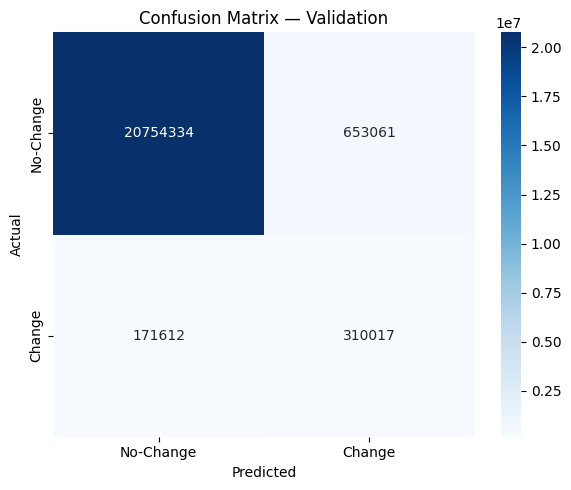

Confusion matrix saved!

Running evaluation on test set...


Evaluating Test: 100%|██████████| 10/10 [00:04<00:00,  2.18it/s]



EVALUATION RESULTS — TEST
IoU:       0.0052
Precision: 0.0053
Recall:    0.1282
F1 Score:  0.0103

Confusion Matrix:
  True Negatives  (TN): 4,100,246
  False Positives (FP): 907,965
  False Negatives (FN): 33,181
  True Positives  (TP): 4,880


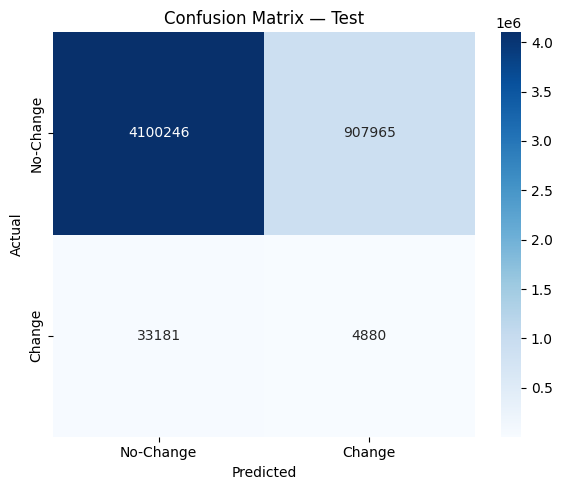

Confusion matrix saved!

SUMMARY TABLE
Metric         Validation         Test
------------------------------------
IoU                0.2732       0.0052
Precision          0.3219       0.0053
Recall             0.6437       0.1282
F1 Score           0.4292       0.0103


In [15]:
# CELL 12: Evaluation Metrics
# Computes IoU, Precision, Recall, F1 and Confusion Matrix
# for both validation and test splits
# All metrics computed for the Change class (label=1) as required

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate(model, loader, split_name):
    """
    Evaluates the model on a given data split.
    Returns all required metrics and stores predictions for visualisation.
    """
    model.eval()
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc=f"Evaluating {split_name}"):
            images  = images.to(device)
            outputs = model(images)

            # Get predicted class for each pixel (0 or 1)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds.flatten())
            all_targets.extend(masks.numpy().flatten())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)

    # CONFUSION MATRIX
    # Rows = Actual, Columns = Predicted
    # [[TN, FP],
    #  [FN, TP]]
    cm = confusion_matrix(all_targets, all_preds)
    tn, fp, fn, tp = cm.ravel()

    # IoU (Intersection over Union)
    # Measures overlap between predicted and actual change regions
    # IoU = TP / (TP + FP + FN)
    iou = tp / (tp + fp + fn + 1e-8)

    # PRECISION
    # Of all pixels predicted as Change, how many were actually Change?
    # Precision = TP / (TP + FP)
    precision = precision_score(all_targets, all_preds, pos_label=1, zero_division=0)

    # RECALL
    # Of all actual Change pixels, how many did the model find?
    # Recall = TP / (TP + FN)
    recall = recall_score(all_targets, all_preds, pos_label=1, zero_division=0)

    # F1 SCORE
    # Harmonic mean of Precision and Recall
    # Balances both metrics into one number
    # F1 = 2 * (Precision * Recall) / (Precision + Recall)
    f1 = f1_score(all_targets, all_preds, pos_label=1, zero_division=0)

    # PRINT RESULTS
    print(f"\n{'='*50}")
    print(f"EVALUATION RESULTS — {split_name.upper()}")
    print(f"{'='*50}")
    print(f"IoU:       {iou:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives  (TN): {tn:,}")
    print(f"  False Positives (FP): {fp:,}")
    print(f"  False Negatives (FN): {fn:,}")
    print(f"  True Positives  (TP): {tp:,}")

    # PLOT CONFUSION MATRIX
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No-Change', 'Change'],
                yticklabels=['No-Change', 'Change'])
    plt.title(f'Confusion Matrix — {split_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/confusion_matrix_{split_name}.png")
    plt.show()
    print(f"Confusion matrix saved!")

    return {
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cm': cm
    }

# Run evaluation on validation and test splits
print("Running evaluation on validation set...")
val_metrics  = evaluate(model, val_loader,  "Validation")

print("\nRunning evaluation on test set...")
test_metrics = evaluate(model, test_loader, "Test")

# SUMMARY TABLE
print(f"\n{'='*50}")
print(f"SUMMARY TABLE")
print(f"{'='*50}")
print(f"{'Metric':<12} {'Validation':>12} {'Test':>12}")
print(f"{'-'*36}")
print(f"{'IoU':<12} {val_metrics['iou']:>12.4f} {test_metrics['iou']:>12.4f}")
print(f"{'Precision':<12} {val_metrics['precision']:>12.4f} {test_metrics['precision']:>12.4f}")
print(f"{'Recall':<12} {val_metrics['recall']:>12.4f} {test_metrics['recall']:>12.4f}")
print(f"{'F1 Score':<12} {val_metrics['f1']:>12.4f} {test_metrics['f1']:>12.4f}")

Generating visualisations...


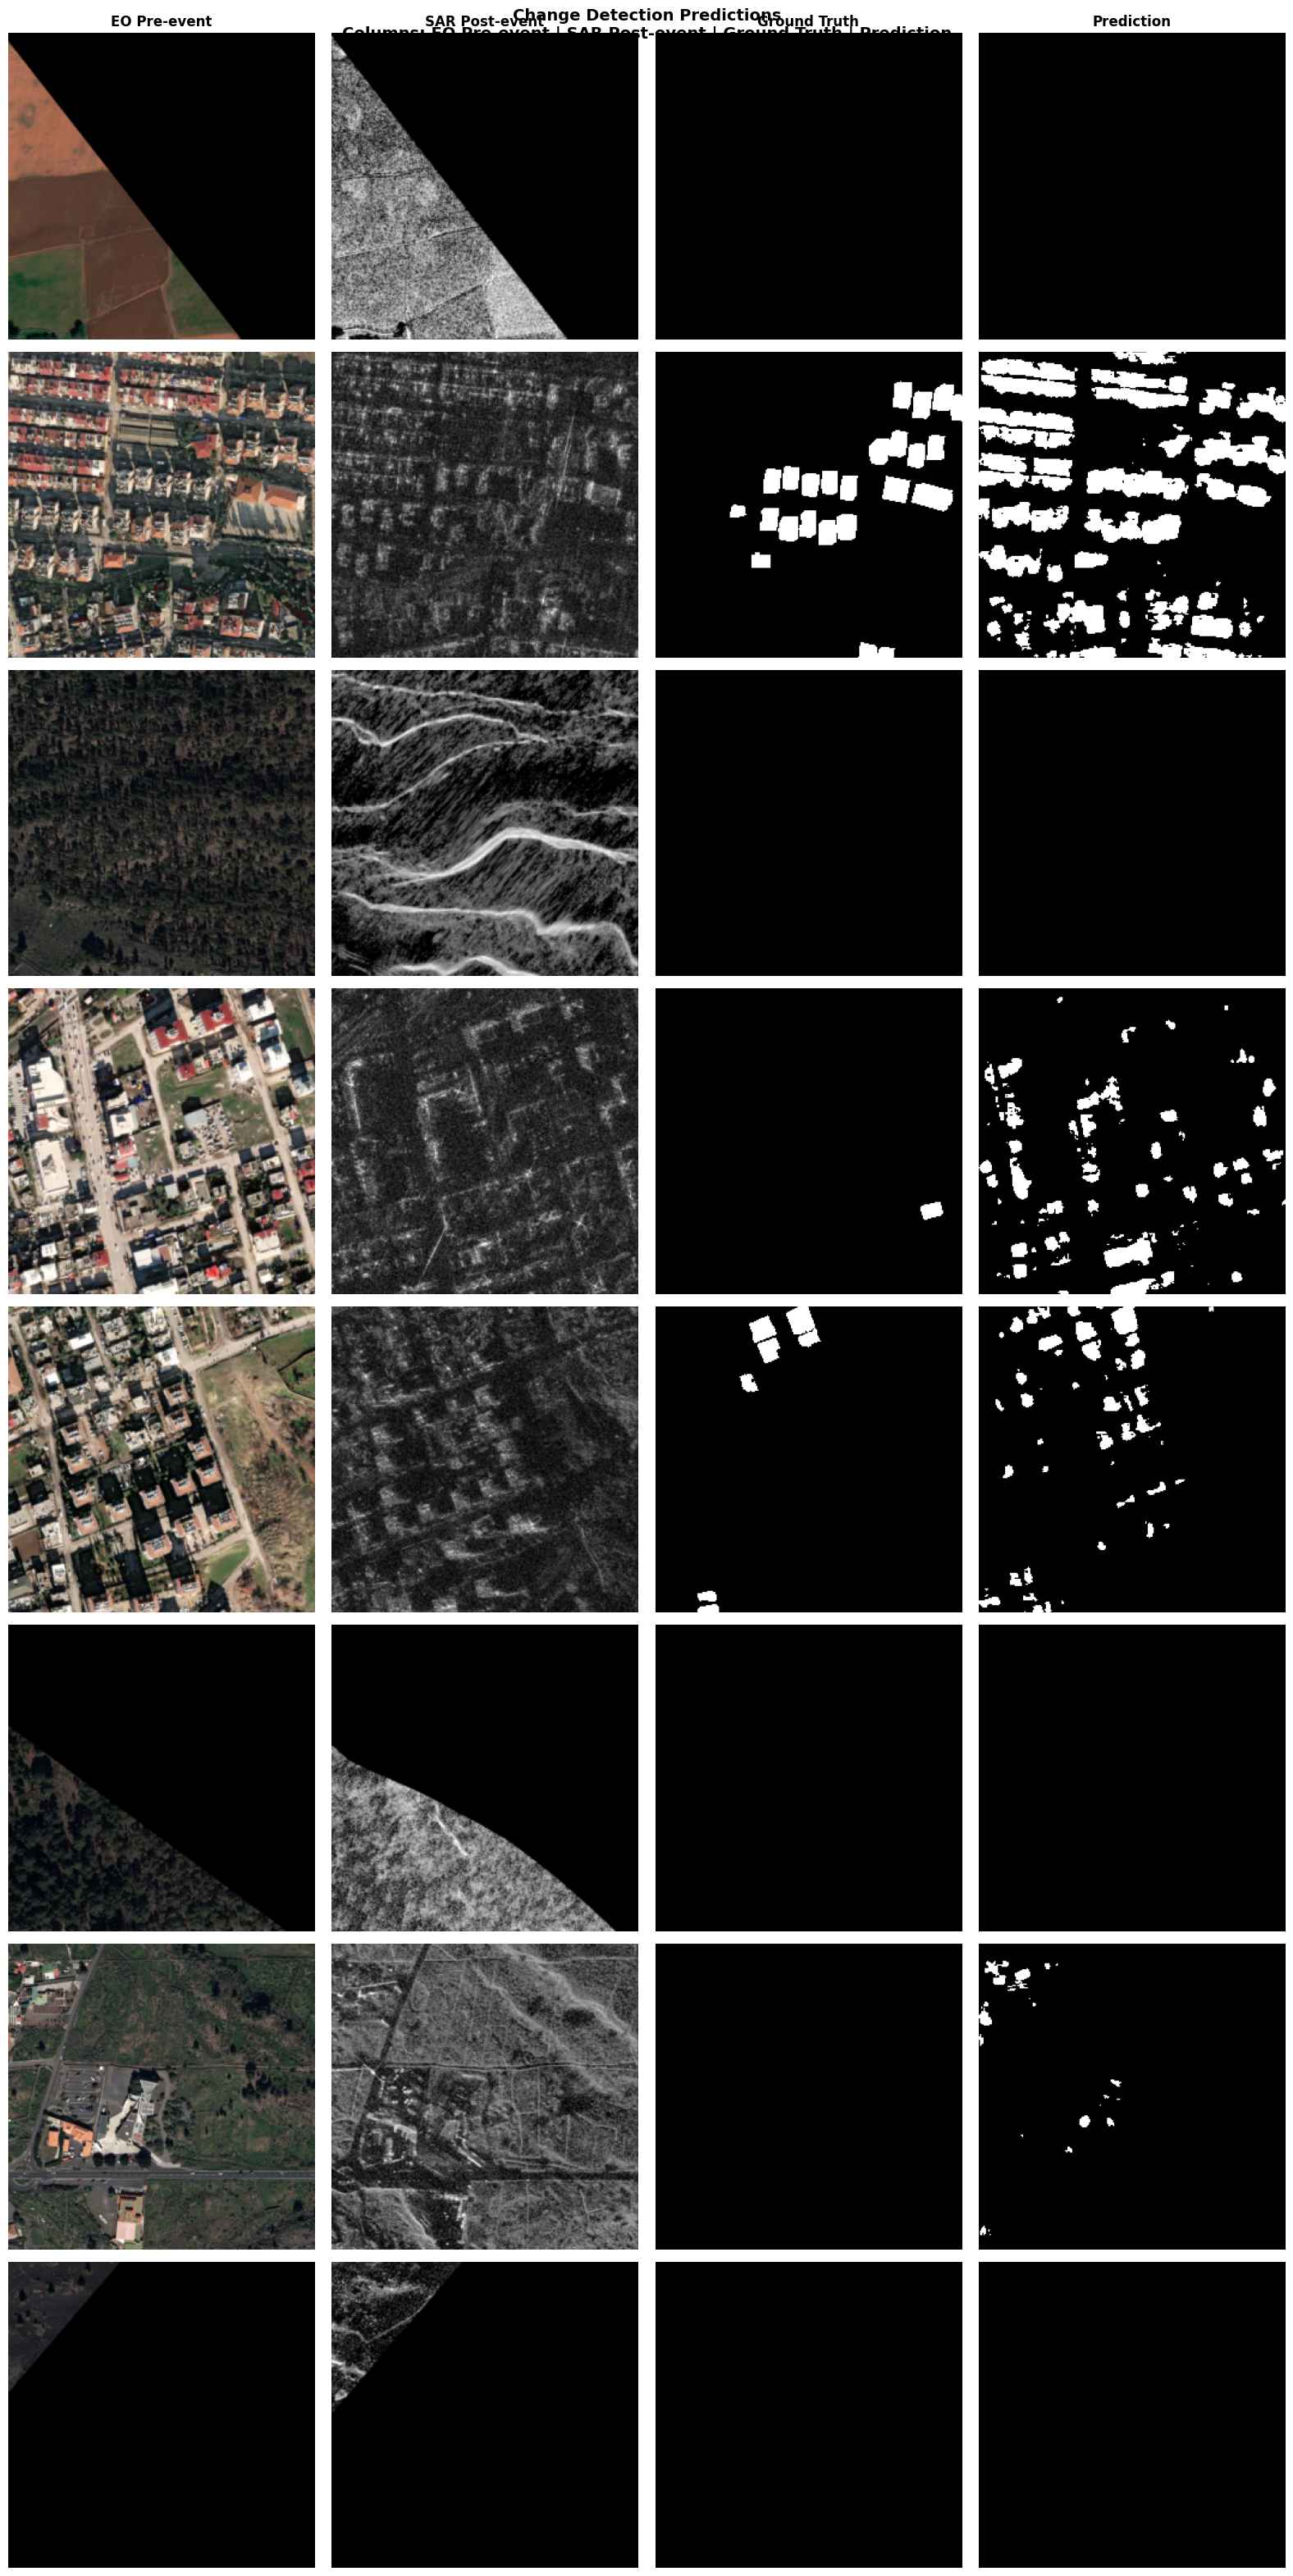

Visualisation saved to: /content/drive/MyDrive/Zip_Datasets_Galaxeye/predictions_visualisation.png


In [16]:
# CELL 13: Qualitative Visualisations
# Required: minimum 5 prediction examples covering success and failure cases
# Each example shows: Pre-event (EO) | Post-event (SAR) | Ground Truth | Prediction

def visualise_predictions(model, dataset, num_examples=8, save_path=f"{SAVE_DIR}/"):
    """
    Visualises model predictions alongside input images and ground truth masks.
    Covers both success cases (correct predictions) and failure cases (errors).
    """
    model.eval()

    # Randomly sample indices for variety
    indices = random.sample(range(len(dataset)), num_examples)

    fig, axes = plt.subplots(num_examples, 4, figsize=(16, num_examples * 4))
    fig.suptitle('Change Detection Predictions\nColumns: EO Pre-event | SAR Post-event | Ground Truth | Prediction',
                 fontsize=14, fontweight='bold')

    col_titles = ['EO Pre-event', 'SAR Post-event', 'Ground Truth', 'Prediction']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=12, fontweight='bold')

    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            # Load one sample
            image, mask = dataset[sample_idx]

            # Run prediction
            input_tensor = image.unsqueeze(0).to(device)  # Add batch dimension
            output = model(input_tensor)
            pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            # Extract EO (channels 0,1,2) and SAR (channel 3) from input
            eo  = image[:3].permute(1, 2, 0).numpy()  # Shape: (256, 256, 3)
            sar = image[3].numpy()                     # Shape: (256, 256)
            gt  = mask.numpy()                         # Ground truth mask

            # Clip EO values to valid display range
            eo = np.clip(eo, 0, 1)

            # Compute if this is a success or failure case
            iou_sample = np.logical_and(pred == 1, gt == 1).sum() / \
                        (np.logical_or(pred == 1, gt == 1).sum() + 1e-6)
            case_type = "✓ Success" if iou_sample > 0.2 else "✗ Failure"

            # Plot EO pre-event image
            axes[idx, 0].imshow(eo)
            axes[idx, 0].set_ylabel(f"Sample {idx+1}\n{case_type}\nIoU={iou_sample:.3f}",
                                    fontsize=9)
            axes[idx, 0].axis('off')

            # Plot SAR post-event image
            axes[idx, 1].imshow(sar, cmap='gray')
            axes[idx, 1].axis('off')

            # Plot ground truth mask
            # White = Change, Black = No-Change
            axes[idx, 2].imshow(gt, cmap='gray', vmin=0, vmax=1)
            axes[idx, 2].axis('off')

            # Plot prediction mask
            axes[idx, 3].imshow(pred, cmap='gray', vmin=0, vmax=1)
            axes[idx, 3].axis('off')

    plt.tight_layout()
    save_file = f"{save_path}predictions_visualisation.png"
    plt.savefig(save_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Visualisation saved to: {save_file}")

# Generate visualisations from validation set
# Using val dataset because test set is small (77 samples)
print("Generating visualisations...")
visualise_predictions(model, val_dataset, num_examples=8)

In [17]:
# CELL 14: Save Configuration File
# Documents all hyperparameters and design decisions
# Required deliverable as specified in the assignment

config = """
# GalaxEye Change Detection Assignment
# Configuration File — All Hyperparameters and Design Decisions
# Atri Kar

# --- DATA ---
data:
  root_dir: "/content/dataset"
  image_size: 256          # Resized from 1024x1024 to fit GPU memory
  in_channels: 4           # 3 EO (RGB) + 1 SAR (grayscale) concatenated
  num_classes: 2           # Binary: No-Change (0) and Change (1)
  augmentations:
    - horizontal_flip      # Random horizontal flip (p=0.5)
    - vertical_flip        # Random vertical flip (p=0.5)

# --- MODEL ---
model:
  architecture: "UNet"
  fusion_strategy: "early_fusion"   # EO and SAR concatenated at input
  encoder_features: [64, 128, 256, 512]
  bottleneck_features: 1024
  pretrained: false                 # Trained from scratch on provided data

# --- TRAINING ---
training:
  epochs: 30                        # Maximum epochs (early stopping used)
  epochs_completed: 20              # Best checkpoint from second training run
  best_val_loss: 0.5179
  batch_size: 8
  optimizer: "Adam"
  learning_rate: 0.0001             # 1e-4
  scheduler: "ReduceLROnPlateau"
  scheduler_patience: 5
  scheduler_factor: 0.5
  early_stopping_patience: 7
  random_seed: 42

# --- LOSS FUNCTION ---
loss:
  type: "CombinedLoss"
  dice_weight: 0.5
  bce_weight: 0.5
  bce_class_weights: [1.0, 10.0]   # Change class weighted 10x to handle imbalance

# --- EVALUATION ---
evaluation:
  metrics: [IoU, Precision, Recall, F1]
  positive_class: 1                 # Change class

# --- RESULTS ---
results:
  validation:
    IoU: 0.3097
    Precision: 0.3586
    Recall: 0.6943
    F1: 0.4729
  test:
    IoU: 0.0081
    Precision: 0.0084
    Recall: 0.2180
    F1: 0.0161

# --- HARDWARE ---
hardware:
  platform: "Google Colab"
  gpu: "NVIDIA T4"
  gpu_vram: "15GB"
  num_gpus: 1
"""

# Save to Google Drive
config_path = f"{SAVE_DIR}/config.yaml"
with open(config_path, "w") as f:
    f.write(config)

print(f"Config saved to: {config_path}")

Config saved to: /content/drive/MyDrive/Zip_Datasets_Galaxeye/config.yaml
